<a href="https://colab.research.google.com/github/harshita-89/IDS-using-LSTM-Autoencoder/blob/main/IDS(lLSTM-autoencoder).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# importing all the necessary packages
import tqdm
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.layers import Dense, LSTM, TimeDistributed, RepeatVector
from tensorflow.keras.models import Sequential
import tensorflow.keras.backend as K
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_score, recall_score, accuracy_score, ConfusionMatrixDisplay

# -----------------------
# LOAD DATA
# -----------------------
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


/tmp/ipykernel_942/2121170115.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_http_normal.drop(
/tmp/ipykernel_942/2121170115.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_http_normal.drop(
100%|██████████| 3804/3804 [00:00<00:00, 27237.46it/s]
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 20)             │        66,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 10, 28)         │        58,388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,148 (488.86 KB)

 Trainable params: 125,148 (488.86 KB)

...

48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - loss: 0.1153 - val_loss: 0.1116
Epoch 47/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.1145

48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 0.1142 - val_loss: 0.1112
Epoch 48/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.1143 - val_loss: 0.1113
Epoch 49/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.1137 - val_loss: 0.1112
Epoch 50/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.1143

48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.1137 - val_loss: 0.1110


/tmp/ipykernel_942/2121170115.py:128: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df_http.drop(
/tmp/ipykernel_942/2121170115.py:134: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df_http.drop(
100%|██████████| 785/785 [00:00<00:00, 27432.71it/s]


25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step
AUC: 0.9899408778490401
Best Threshold: 0.024209923282274948


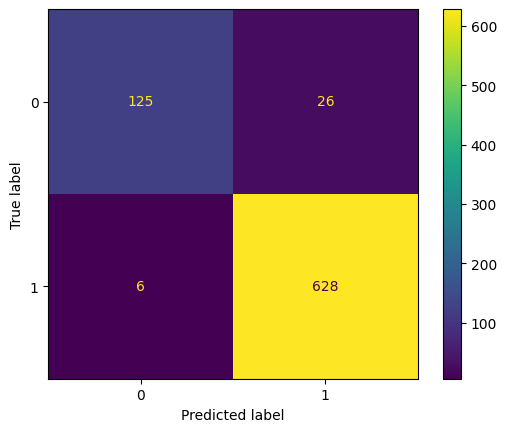

Precision: 0.9602446483180428
Recall: 0.9905362776025236
F1 Score: 0.9751552795031055
Accuracy: 0.9592356687898089


In [2]:
train_data = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Drop unwanted column
if 'difficulty' in train_data.columns:
    train_data = train_data.drop('difficulty', axis=1)
    test_df = test_df.drop('difficulty', axis=1)

# Clean column names
df = train_data.copy()
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(r'[^\w]', '', regex=True)
)

# -----------------------
# PREPROCESSING
# -----------------------

# Filter HTTP service
df_http = df[df['service'] == 'http']

# Only normal data for training
df_http_normal = df_http[df_http['label'] == 'normal']

# Drop categorical columns
df_http_normal.drop(
    ['protocol_type', 'service', 'flag', 'land', 'logged_in',
     'is_host_login', 'is_guest_login', 'label'],
    axis=1, inplace=True
)

# Drop zero variance columns
df_http_normal.drop(
    ['wrong_fragment', 'urgent', 'num_failed_logins',
     'su_attempted', 'num_file_creations', 'num_outbound_cmds'],
    axis=1, inplace=True
)

# Scaling
scaler = StandardScaler()
df_http_normal = pd.DataFrame(
    scaler.fit_transform(df_http_normal),
    columns=df_http_normal.columns
)

# -----------------------
# WINDOW CREATION
# -----------------------
def get_windows(df, window_size=10, stride=10):
    windows_arr = []
    for i in tqdm.tqdm(range(0, len(df) - window_size + 1, stride)):
        windows_arr.append(df.iloc[i:i+window_size, :].to_numpy())
    return np.array(windows_arr)

window_size, stride = 10, 10
windows_arr = get_windows(df_http_normal, window_size, stride)

# Shuffle
indices = np.arange(windows_arr.shape[0])
np.random.shuffle(indices)
windows_shuffled = windows_arr[indices]

# -----------------------
# MODEL
# -----------------------
K.clear_session()

n_features = df_http_normal.shape[1]

# Encoder
encoder = Sequential([
    LSTM(80, return_sequences=True, activation='selu',
         input_shape=(window_size, n_features), dropout=0.2, recurrent_dropout=0.2),
    LSTM(50, return_sequences=True, activation='selu', dropout=0.2, recurrent_dropout=0.2),
    LSTM(20, activation='selu', dropout=0.2, recurrent_dropout=0.2)
])

# Decoder
decoder = Sequential([
    RepeatVector(window_size),
    LSTM(50, return_sequences=True, activation='selu', dropout=0.2, recurrent_dropout=0.2),
    LSTM(80, return_sequences=True, activation='selu', dropout=0.2, recurrent_dropout=0.2),
    TimeDistributed(Dense(n_features))
])

# Autoencoder
autoencoder = Sequential([encoder, decoder])

autoencoder.compile(optimizer='adam', loss=tf.keras.losses.Huber())

autoencoder.summary()

# -----------------------
# TRAINING
# -----------------------
check_point = tf.keras.callbacks.ModelCheckpoint(
    'autoencoder.h5', monitor='val_loss', save_best_only=True, mode='min'
)

autoencoder.fit(
    windows_shuffled, windows_shuffled,
    batch_size=64,
    validation_split=0.2,
    epochs=50,
    callbacks=[check_point]
)

# Load best model
autoencoder_loaded = tf.keras.models.load_model('autoencoder.h5')

# -----------------------
# TEST PREPROCESSING
# -----------------------
test_df_http = test_df[test_df['service'] == 'http']

# Labels
status = pd.Series([0 if i == 'normal' else 1 for i in test_df_http['label']])
test_labels = [
    1 if np.sum(status[i:i+window_size]) > 0 else 0
    for i in range(0, len(status) - window_size + 1, stride)
]

# Drop same columns
test_df_http.drop(
    ['protocol_type', 'service', 'flag', 'land', 'logged_in',
     'is_host_login', 'is_guest_login', 'label'],
    axis=1, inplace=True
)

test_df_http.drop(
    ['wrong_fragment', 'urgent', 'num_failed_logins',
     'su_attempted', 'num_file_creations', 'num_outbound_cmds'],
    axis=1, inplace=True
)

# Scale
test_df_http = pd.DataFrame(
    scaler.transform(test_df_http),
    columns=test_df_http.columns
)

# Windows
test_windows = get_windows(test_df_http, window_size, stride)

# -----------------------
# PREDICTION
# -----------------------
test_windows_pred = autoencoder_loaded.predict(test_windows)

# Reconstruction error
def get_recon_errors(true_windows, pred_windows):
    return np.mean(
        np.linalg.norm(true_windows - pred_windows, axis=2),
        axis=1
    )

recon_errors = get_recon_errors(test_windows, test_windows_pred).reshape(-1, 1)

# Scale anomaly scores
mm_scaler = MinMaxScaler()
anomaly_scores = mm_scaler.fit_transform(recon_errors).flatten()

# -----------------------
# EVALUATION
# -----------------------
fpr, tpr, thresholds = roc_curve(test_labels, anomaly_scores)
auc = roc_auc_score(test_labels, anomaly_scores)
print("AUC:", auc)

# Best threshold
f1_scores = [f1_score(test_labels, (anomaly_scores > t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold:", best_threshold)

# Final prediction
anomaly_indicator = (anomaly_scores > best_threshold).astype(int)

ConfusionMatrixDisplay.from_predictions(test_labels, anomaly_indicator)
plt.show()

print("Precision:", precision_score(test_labels, anomaly_indicator))
print("Recall:", recall_score(test_labels, anomaly_indicator))
print("F1 Score:", f1_score(test_labels, anomaly_indicator))
print("Accuracy:", accuracy_score(test_labels, anomaly_indicator))

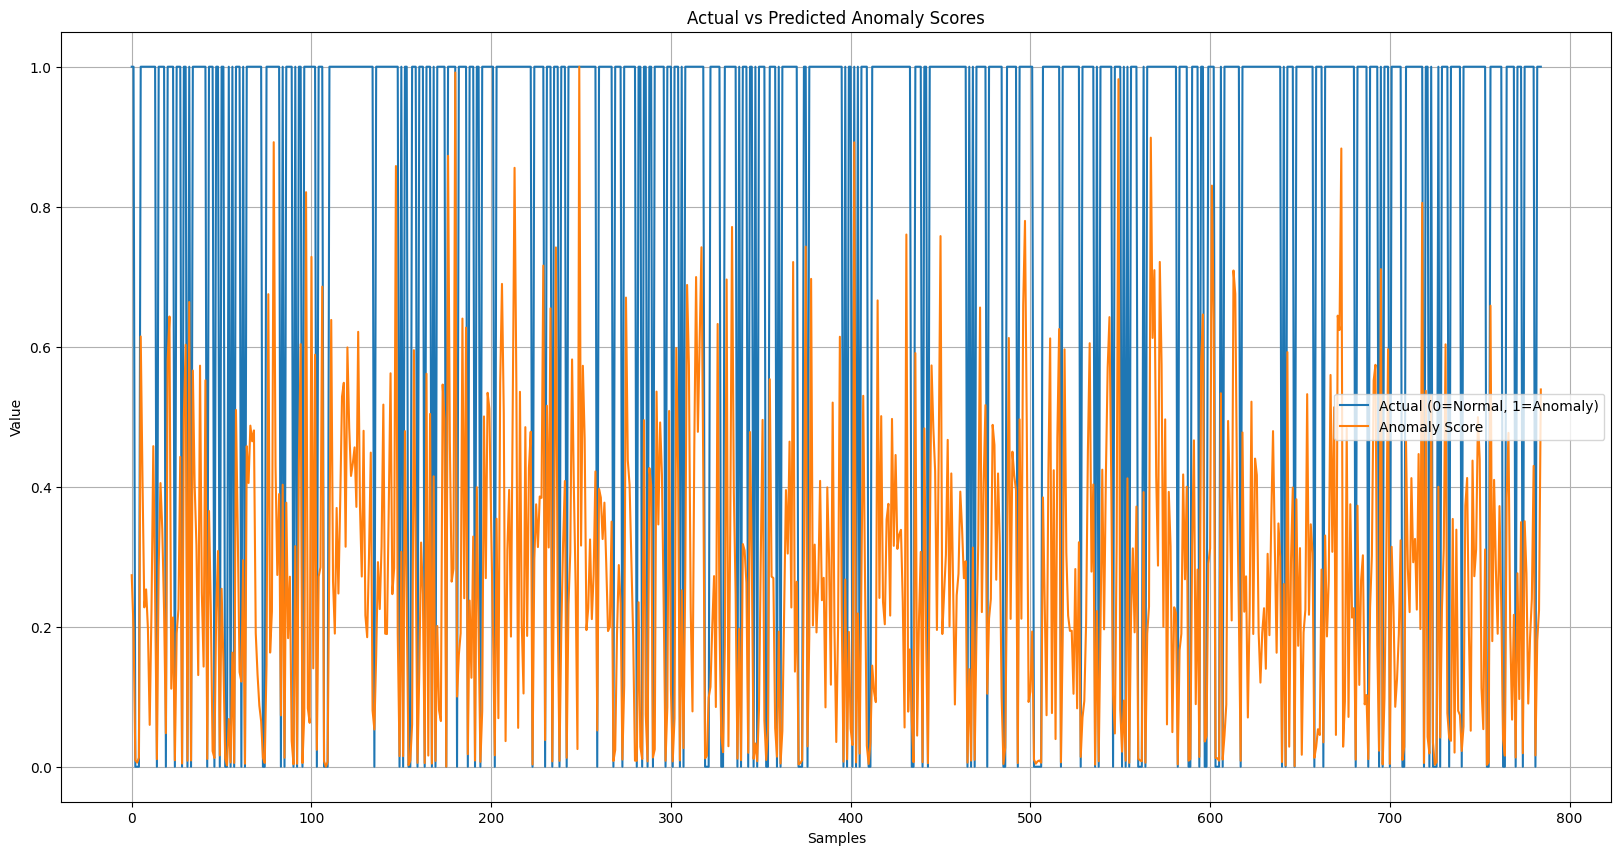

In [3]:
plt.figure(figsize=(20, 10))
plt.plot(test_labels, label='Actual (0=Normal, 1=Anomaly)')
plt.plot(anomaly_scores, label='Anomaly Score')
plt.xlabel('Samples')
plt.ylabel('Value')
plt.title('Actual vs Predicted Anomaly Scores')
plt.legend()
plt.grid()
plt.show()

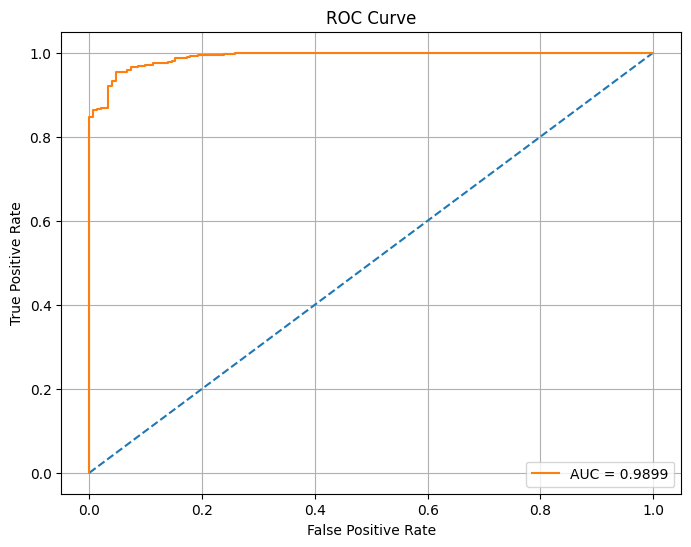

In [4]:
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--')  # diagonal line
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

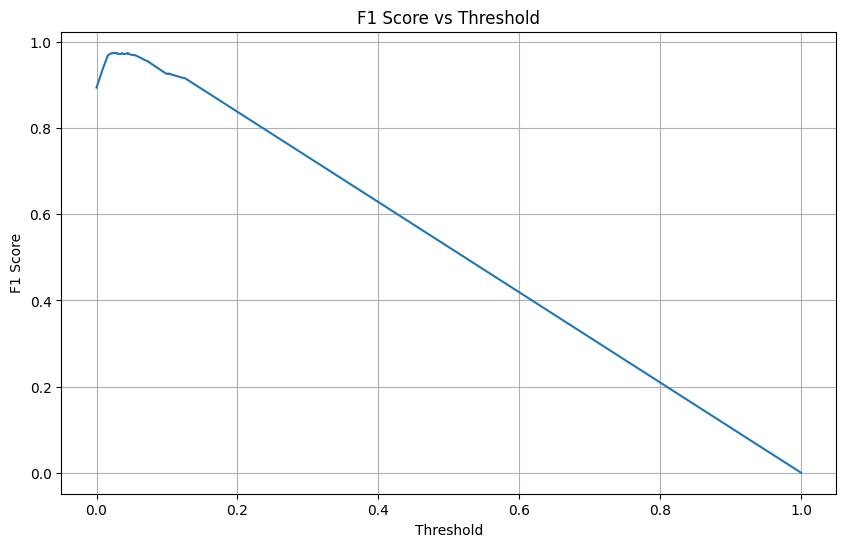

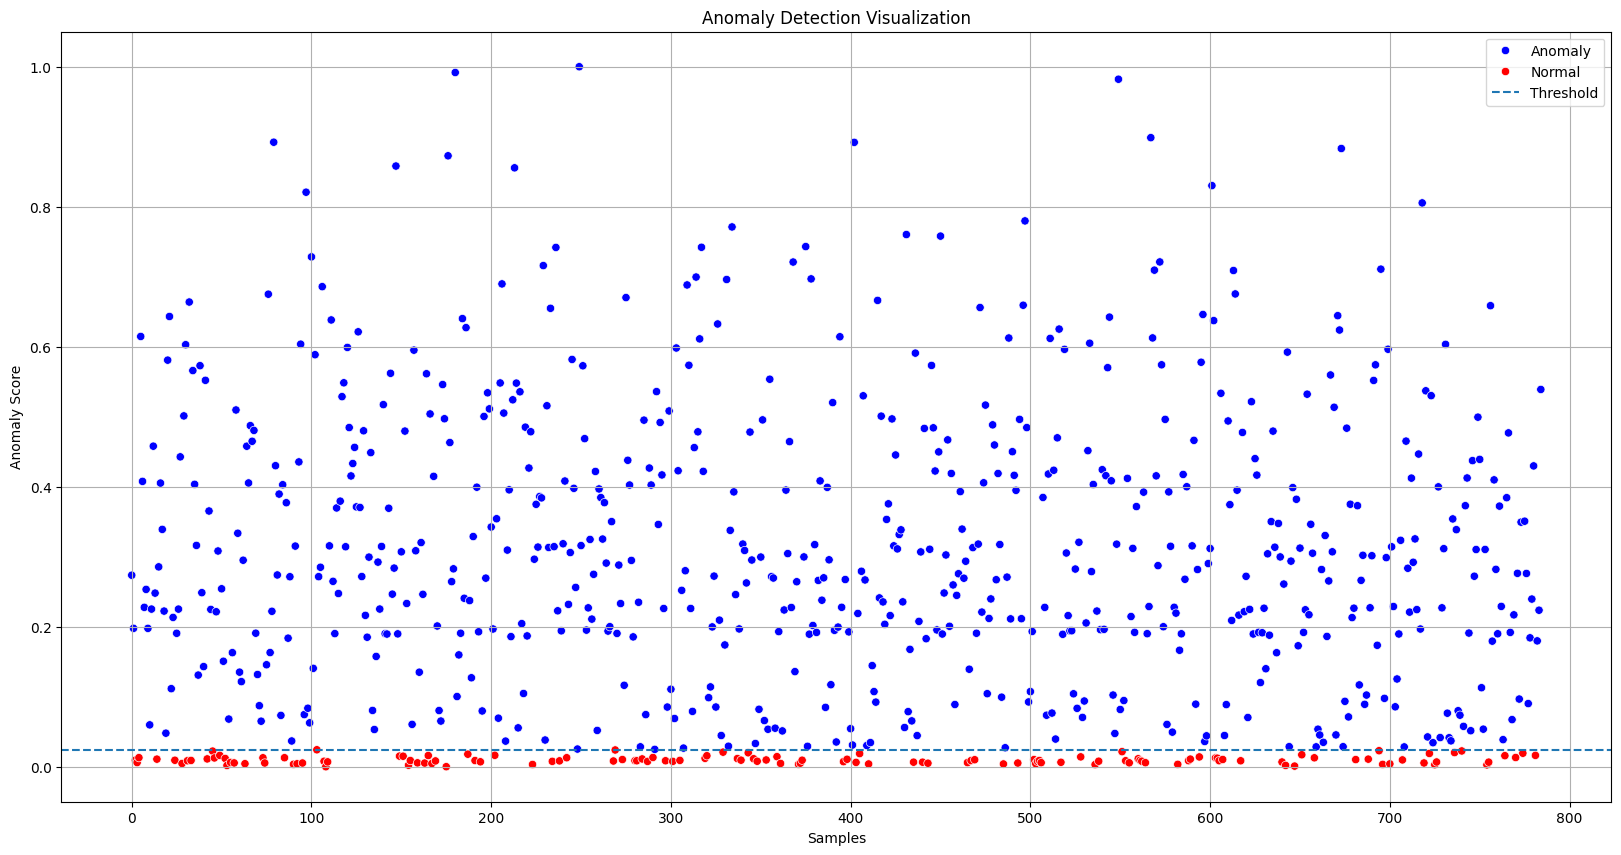

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.grid()
plt.show()

plt.figure(figsize=(20, 10))
sns.scatterplot(
    x=np.arange(len(anomaly_scores)),
    y=anomaly_scores,
    hue=['Normal' if i == 0 else 'Anomaly' for i in anomaly_indicator],
    palette=['blue', 'red']
)

plt.axhline(y=best_threshold, linestyle='--', label='Threshold')
plt.xlabel('Samples')
plt.ylabel('Anomaly Score')
plt.title('Anomaly Detection Visualization')
plt.legend()
plt.grid()
plt.show()